# Load Data

This notebook loads in the workout data and show the data strucure and types. 

The goal of the notebook is the join the datasets if possible and to make sure that the data is in the right format for the next steps of the project.

# Workout data Lyfta


In [234]:
# import
import pandas as pd
import matplotlib.pyplot as plt

In [235]:
workout_data = pd.read_csv("workout_data.csv")


(workout_data.head())

,Title,Date,Duration,Description,Notes,Exercise,Exercise Note,Superset id,Weight,Reps,RIR/RPE,Distance,Time,Set Type,RecordLevel: gold/silver/bronze,RecordType: 1RM / max_weight / volume / reps
0,Evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,Full Squat,NaN,NaN,80.0,8.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN
1,Evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,Full Squat,NaN,NaN,90.0,8.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN
2,Evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,Full Squat,NaN,NaN,90.0,8.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN
3,Evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,Lever Seated Leg Press,NaN,NaN,120.0,6.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN
4,Evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,Lever Seated Leg Press,NaN,NaN,120.0,6.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN


This show the first 5 rows of the workout data that was loaded from Lyfta. This is to ensure that the data is loaded correctly and to get a sense of the data structure.

This shows that the data contains the Title of the workout, the date with time stamp, the duration of the workout, the name of the exercise, the weight, reps, type of set and the record level.

In [236]:
workout_data.shape

(4404, 16)

The dataset contain 4404 rows and 16 columns. Not every column is relevant or contains dats, this will be explored later in the notebook.

# Workout data Basic fit

I exported my basic fit data from the site as a JSON file and convert it into a csv file. This data will be added to the other dataset to have a clear overivew of my weight over the course of the years.

In [237]:
import json
# load the dataset from the json file and convert  to a dataframe
with open('basic-fit.json', encoding='utf-8') as f:
    data_basicfit = json.load(f)

df_basicfit_old = pd.DataFrame(data_basicfit['stats'])


df_basicfit_new = pd.DataFrame(data_basicfit['measurements'])    

In [238]:
print(f"{df_basicfit_old.shape}: shape of the old dataset")
print(f"{df_basicfit_new.shape}: shape of the new dataset")

# show column names
print(f"Column names of basic fit data old: {df_basicfit_old.columns}")
print(f"Column names of basic fit data new: {df_basicfit_new.columns}")




(537, 6): shape of the old dataset
(15, 8): shape of the new dataset
Column names of basic fit data old: Index(['day', 'gymVisits', 'bone', 'fat', 'muscle', 'weight'], dtype='object')
Column names of basic fit data new: Index(['date', 'fat', 'muscle', 'bone', 'water', 'weight', 'calories',
       'height'],
      dtype='object')


This shows the the old data structure contain 537 rows and 6 columns, and the new contains 15 row and 8 columns. 



In [239]:
old = df_basicfit_old.columns.tolist()
new = df_basicfit_new.columns.tolist()

print(old)

print("the colums that are in the old dataset that the new one doesnt contain are:")
for col in old:
    if not col in new:
        print(col)
        
print("\n")

print(new)
print("the colums that are in the new dataset that the old one doesnt contain are:")
for col in new:
    if not col in old:
        print(col)


['day', 'gymVisits', 'bone', 'fat', 'muscle', 'weight']
the colums that are in the old dataset that the new one doesnt contain are:
day
gymVisits


['date', 'fat', 'muscle', 'bone', 'water', 'weight', 'calories', 'height']
the colums that are in the new dataset that the old one doesnt contain are:
date
water
calories
height


In [240]:
# change data to datatime type

df_basicfit_new['date'] = pd.to_datetime(df_basicfit_new['date'], errors='coerce').dt.strftime('%Y-%m-%d')
df_basicfit_old['date'] = pd.to_datetime(df_basicfit_old['day'], errors='coerce').dt.strftime('%Y-%m-%d')



In [241]:
df_basicfit_new.dtypes


date         object
fat         float64
muscle      float64
bone        float64
water       float64
weight      float64
calories     object
height      float64
dtype: object

This shows that the datatype of the date changed to `datetime`

## Check duplicates

In [242]:
# subset of the new dataset
sub_new = df_basicfit_new[['date', 'weight']]

# subset of the old dataset
sub_old = df_basicfit_old[['date', 'weight']]

print(f"shape of the old dataset {sub_old.shape}")

print(f"shape of the new dataset {sub_new.shape}")

shape of the old dataset (537, 2)
shape of the new dataset (15, 2)


In [243]:
result = sub_old.merge(
    sub_new,
    on=['weight', 'date'],
    how='left',
    indicator=True
)

# Show count overview
print(result['_merge'].value_counts())
(result[result['_merge'] == 'both'])


_merge
left_only     522
both           15
right_only      0
Name: count, dtype: int64


,date,weight,_merge
370,2025-05-07,69.3,both
382,2025-05-25,69.1,both
387,2025-06-03,69.2,both
396,2025-06-20,67.8,both
397,2025-06-22,68.6,both
416,2025-07-25,68.5,both
418,2025-07-28,69.1,both
427,2025-09-03,68.3,both
439,2025-09-24,69.0,both
446,2025-10-12,70.0,both


this shows that the new dataset contains the same data as the old dataset. this could indicate that the data structure changed and the old name was measurements, but the data is the same. 

In this case only the old dataset will be used, since it contains more data and the new dataset is just a subset of the old dataset.

In [244]:
df_basicfit = df_basicfit_old[['date', 'weight']]

## Add weight to workout data

In [245]:
# add short date for the join with weight data
workout_data['Date_short'] = pd.to_datetime(workout_data['Date'], errors='coerce').dt.strftime('%Y-%m-%d')
workout_data['Date'] = pd.to_datetime(workout_data['Date'], errors='coerce').dt.strftime('%Y-%m-%d %H:%M:%S')

In [246]:
workout_data.head()

,Title,Date,Duration,Description,Notes,Exercise,Exercise Note,Superset id,Weight,Reps,RIR/RPE,Distance,Time,Set Type,RecordLevel: gold/silver/bronze,RecordType: 1RM / max_weight / volume / reps,Date_short
0,Evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,Full Squat,NaN,NaN,80.0,8.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN,2026-03-29
1,Evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,Full Squat,NaN,NaN,90.0,8.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN,2026-03-29
2,Evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,Full Squat,NaN,NaN,90.0,8.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN,2026-03-29
3,Evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,Lever Seated Leg Press,NaN,NaN,120.0,6.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN,2026-03-29
4,Evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,Lever Seated Leg Press,NaN,NaN,120.0,6.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN,2026-03-29


In [247]:
# join the workout data with the weight data
workout_data_joined = workout_data.merge(df_basicfit, left_on='Date_short', right_on='date', how='left', indicator=True)

print(workout_data_joined['_merge'].value_counts())

_merge
both          4392
left_only       12
right_only       0
Name: count, dtype: int64


This shows that the data is joined correctly, but that the are 12 workouts  dates that doesn't exist in the basic-fit dataset. Each row in the basic fit dataset is a day that I went to the basic, it doens't mean that I also weight myself. 

`left_only 12` means that there are 12 workouts that didn't took place in the gym. This can be the time when I didn't use the app.

In [248]:
workout_data_joined[workout_data_joined['_merge'] == 'left_only']

,Title,Date,Duration,Description,Notes,Exercise,Exercise Note,Superset id,Weight,Reps,RIR/RPE,Distance,Time,Set Type,RecordLevel: gold/silver/bronze,RecordType: 1RM / max_weight / volume / reps,Date_short,date,weight,_merge
2979,Evening session,2025-03-14 22:15:00,00:42:40,NaN,NaN,Push-up,NaN,NaN,66.0,10.0,NaN,NaN,NaN,NORMAL_SET,1,1,2025-03-14,NaN,NaN,left_only
2980,Evening session,2025-03-14 22:15:00,00:42:40,NaN,NaN,Push-up,NaN,NaN,66.0,10.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN,2025-03-14,NaN,NaN,left_only
2981,Evening session,2025-03-14 22:15:00,00:42:40,NaN,NaN,Push-up,NaN,NaN,66.0,10.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN,2025-03-14,NaN,NaN,left_only
2982,Evening session,2025-03-14 22:15:00,00:42:40,NaN,NaN,Dip on Floor with Chair,NaN,NaN,66.0,10.0,NaN,NaN,NaN,NORMAL_SET,1,1,2025-03-14,NaN,NaN,left_only
2983,Evening session,2025-03-14 22:15:00,00:42:40,NaN,NaN,Dip on Floor with Chair,NaN,NaN,66.0,10.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN,2025-03-14,NaN,NaN,left_only
2984,Evening session,2025-03-14 22:15:00,00:42:40,NaN,NaN,Dip on Floor with Chair,NaN,NaN,66.0,10.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN,2025-03-14,NaN,NaN,left_only
2985,Evening session,2025-03-14 22:15:00,00:42:40,NaN,NaN,Pseudo Planche Push-up,NaN,NaN,66.0,8.0,NaN,NaN,NaN,NORMAL_SET,1,1,2025-03-14,NaN,NaN,left_only
2986,Evening session,2025-03-14 22:15:00,00:42:40,NaN,NaN,Pseudo Planche Push-up,NaN,NaN,66.0,8.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN,2025-03-14,NaN,NaN,left_only
2987,Evening session,2025-03-14 22:15:00,00:42:40,NaN,NaN,Pseudo Planche Push-up,NaN,NaN,66.0,8.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN,2025-03-14,NaN,NaN,left_only
2988,Evening session,2025-03-14 22:15:00,00:42:40,NaN,NaN,Archer Push up,NaN,NaN,66.0,8.0,NaN,NaN,NaN,NORMAL_SET,1,1,2025-03-14,NaN,NaN,left_only


Above is the workout that didn't have a basic fit visit connected to it, this can mean that I was a home workout. This conclussion is taken by the lack of weights and the absence of a pull up exercise. 

## Overview of weight data

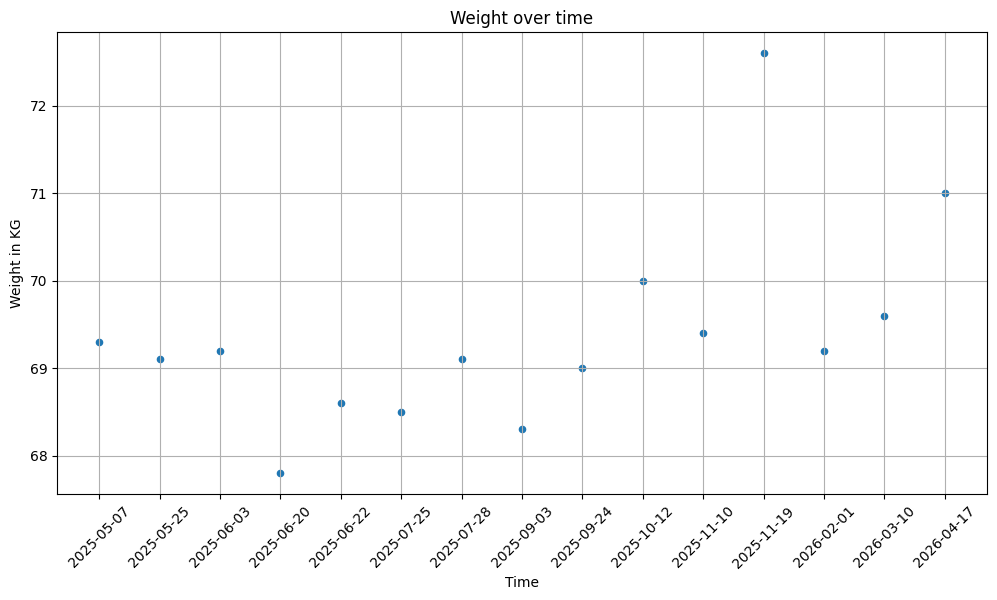

In [253]:


figs, axs = plt.subplots(figsize=(12,6))

df_basicfit_new[['weight', 'date']].plot(x='date', 
                                        y='weight', 
                                        kind='scatter', 
                                        title="Weight over time", 
                                        ylabel="Weight in KG", 
                                        xlabel="Time", 
                                        ax=axs, 
                                        grid=True,
                                        legend=True)

plt.xticks(rotation = 45)
axs.invert_xaxis()

plt.show()


# figs, axs = plt.subplots(figsize=(12,6))

# df_basicfit_old[['weight', 'date']][df_basicfit_old['weight'].notna()].plot(x='date', 
#                                         y='weight', 
#                                         kind='scatter', 
#                                         title="Weight over time", 
#                                         ylabel="Weight in KG", 
#                                         xlabel="Time", 
#                                         ax=axs, 
#                                         grid=False,
#                                         legend=True)


# plt.show()


In [254]:
print(f"There are {(df_basicfit['weight'] == 0).count()} missing values in 'weight'")

print(f"There are {df_basicfit['weight'].count()} filled values in 'weight")

There are 537 missing values in 'weight'
There are 129 filled values in 'weight
